In [2]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field

from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langchain_core.prompts import PromptTemplate

from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv
from huggingface_hub import InferenceClient
import requests, operator, random, sqlite3

In [3]:
load_dotenv()

True

In [4]:
model = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    task="text-generation",
    max_new_tokens=256,
    temperature=0.7
)
llm = ChatHuggingFace(llm=model)

translator_model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7,
    google_api_key=""
)
# translator_model = InferenceClient(model="google/mt5-large")


In [16]:
class SubState(TypedDict):
    input_str: str
    translated: str

In [17]:
def translate_text(state: SubState):
    text = state['input_str']
    prompt = f"Translate this text {text} into Urdu. Keep it natural and clear, don't add extra content."
    # response = translator_model.translation(
    #     text,
    #     src_lang="en",
    #     tgt_lang="ur"
    # )
    # print(response.content)
    response = translator_model.invoke(prompt)
    return {'translated': response.content}



In [18]:
subgraph = StateGraph(SubState)
subgraph.add_node('translate_text', translate_text)

subgraph.add_edge(START, 'translate_text')
subgraph.add_edge('translate_text',END)

Subgraph = subgraph.compile()

In [19]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_urdu: str

In [20]:
def answer_question(state: ParentState):
    inp = state['question']
    prompt = f"You are helpful assistant for my questions. Answer this question concise and clearly. \n\n{inp}"
    answer = llm.invoke(prompt).content

    return {'answer_eng': answer}

In [21]:
def translate_answer(state: ParentState):
    result = Subgraph.invoke({'input_str': state['answer_eng']})
    # Return a dict mapping state key to value
    return {'answer_urdu': result['translated']}

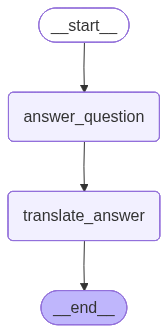

In [22]:
parent_graph = StateGraph(ParentState)

parent_graph.add_node('answer_question', answer_question)
parent_graph.add_node('translate_answer', translate_answer)

parent_graph.add_edge(START, 'answer_question')
parent_graph.add_edge('answer_question', 'translate_answer')
parent_graph.add_edge('translate_answer', END)

graph = parent_graph.compile()
graph


In [ ]:
result = graph.invoke({'question': 'what is machine learning?'})
print(result)

{'question': 'what is machine learning?', 'answer_eng': 'Machine learning is a subset of artificial intelligence that involves developing algorithms and statistical models to enable computers to perform tasks without explicit programming, by learning from and making predictions on data.', 'answer_urdu': 'مشین لرننگ مصنوعی ذہانت کا ایک ذیلی شعبہ ہے جس میں الگورتھم اور شماریاتی ماڈلز تیار کیے جاتے ہیں تاکہ کمپیوٹرز ڈیٹا سے سیکھ کر اور اس پر پیشین گوئیاں کر کے، واضح پروگرامنگ کے بغیر کام انجام دے سکیں۔'}
